# ETF models compared: which of these signals is real

Seven notebooks have fitted models to this panel, across five families and two label horizons.
Each reported its own results against its own declared menu. **None of them could say how it
compares to the others**, because none of them had the others in front of it.

That is what this notebook is for. It reads every registered prediction set for this case study,
puts the families on one axis with their uncertainty, and asks three questions of them: how
strong is the signal, how consistent is it across the walk-forward folds, and are the families
finding the same thing or different things.

**This is a cross-asset panel, and that changes what a signal means here.** The universe mixes
sector equity funds with country funds, bond funds, commodity funds and currency funds, so the
thing a model has to rank is not which company is mispriced but which macro exposure is currently
being rewarded. The instruments are already diversified, which is why cross-sectional information
coefficients on this panel are small by the standards of a single-stock cross-section - there is
less idiosyncratic variation left in them to find.

**It selects nothing.** Selection is best validation backtest Sharpe and it happens in
[`14_backtest`](14_backtest.ipynb), over the population this notebook describes. Every number
here is measured on validation folds that have been read repeatedly by the time a case study
reaches this point; the holdout is opened once, in
[`20_strategy_analysis`](20_strategy_analysis.ipynb).

**Learning objectives**

- Read a family comparison from its confidence intervals rather than from its ordering.
- Separate a mean information coefficient from the fold-level consistency behind it.
- Say whether two model families are finding the same signal or different ones, and what follows.
- Say why structural and causal evidence are read apart from a predictive ranking.

**Book reference**: this notebook bridges Part III (models, chapters 11 to 15) and Part IV
(strategy implementation, chapters 16 to 20). The chapter-insight notebooks compare one family
across case studies; this compares every family within one.

**Prerequisites**: [`06_linear`](06_linear.ipynb) through
[`12_causal_dml`](12_causal_dml.ipynb), whose registered results are what this reads, and
[`05_evaluation`](05_evaluation.ipynb) for the walk-forward folds every number is measured on.

**What it writes**: nothing. It fits no model, registers no run and opens no holdout.

In [1]:
"""Compare every registered ETF model family on one panel, without selecting among them."""

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml
from plotly.subplots import make_subplots

from case_studies.research import CausalResult, open_study, split_unpublished_members
from case_studies.utils.latent_factors import load_fold_extras
from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_render import (
    conformal_coverage_diagnostic,
    fold_heatmap_with_ci,
    headline_forest_plot,
    holdout_decay_table,
    selection_adjusted_leader_table,
)
from case_studies.utils.registry import load_prediction_index
from utils.paths import get_case_study_dir
from utils.style import COLORS, show_plotly_with_alt, show_with_alt

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "etfs"
PRIMARY_LABEL = "fwd_ret_21d"
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15
REGIME_WINDOW = 63
# Both names stay bound here although nothing below reads them: that is what makes the harness
# force preview and supply a workspace - `_declares_tier_and_workspace` in `tests/pm_helpers.py`
# looks for exactly this pair. Without them the canonical
# branch regenerates in place, which needs symlinks a CI checkout does not have.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

The study is opened before anything resolves a path or reads the registry. Under the preview
tier, opening it activates a workspace and rewrites `ML4T_OUTPUT_DIR` process-wide, and every
later `get_case_study_dir` call resolves against that. A `CASE_DIR` or a metrics table built
first would point at the released registry while everything after it reads the preview one.

In [3]:
study = open_study(CASE_STUDY, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

CASE_DIR = get_case_study_dir(CASE_STUDY)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"]["n_assets"]
costs = setup["costs"]
per_share_usd = costs["per_share"]
default_half_spread_usd = costs["default_half_spread_usd"]
# The bucket-monotonicity overlay wants a basis-point band, and this case study prices in cents
# per share; these two anchor the liquid and the sector ends of the universe.
COST_RANGE_BPS = [5, 15]

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: {n_assets} ETFs (equities, bonds, commodities, FX, sectors)")
print(f"  Label: {PRIMARY_LABEL} (monthly rebalancing)")
print(f"  CV: {n_splits} rolling-window folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(
    f"  Trading costs: ${per_share_usd:.4f}/share + tiered half-spread "
    f"(mega 0.5¢, sector 1¢, default {default_half_spread_usd * 100:.0f}¢)"
)

Case Study: etfs
  Universe: 100 ETFs (equities, bonds, commodities, FX, sectors)
  Label: fwd_ret_21d (monthly rebalancing)
  CV: 8 rolling-window folds, train=10Y, val=1Y
  Holdout: 2024-01-01 onwards
  Trading costs: $0.0035/share + tiered half-spread (mega 0.5¢, sector 1¢, default 2¢)


## 1. The prediction problem, and the shape of the evidence

**The target is `fwd_ret_21d`**: the total return over the 21 trading days after the decision
date, predicted for every fund, then ranked cross-sectionally at each rebalance. The strategy the
backtest will build holds the top of that ranking and rebalances monthly, so what a model has to
get right is the ordering within a date rather than the level of any one forecast. The metric is
therefore an information coefficient - the rank correlation between the predicted and the
realized cross-section, averaged over dates.

The panel's proportions are unusual for this book. There are many more dates than funds, which is
the opposite of a single-stock cross-section, and it is what makes latent-factor methods
available here: a small number of common movements can plausibly explain a hundred funds whose
categories - equity sectors, bonds, commodities, currencies - are themselves an economically
meaningful low-rank structure.

The features are entirely price-derived. Momentum at horizons from a week to a year, momentum
adjusted for its own volatility, volatility itself, technical indicators and the yield-curve
slope. There is no fundamental or alternative data, so anything a model finds here is a statement
about price history and nothing else.

The counts printed above come from `config/setup.yaml` and the artifacts, so they describe the
run rather than restating a number that was true when this was written.

**Which generation of each family is being described.** `prediction_metrics` is a catalog, and a
catalog carries no lineage: when a model notebook refits, it publishes a second generation under
the same population name and the generation it replaced stays behind, complete and current under
a schema version that has not moved. Reading the catalog alone therefore lists a family twice -
once as it is published and once as it was - and the representative chosen to stand for the
family in every comparison below can be the retired one.

`split_unpublished_members` asks the population lineage instead, and the excluded side is
printed rather than dropped silently, so the count is auditable against the registry.

It asks **membership** and not retirement, which is the stronger of the two questions and the
one [`14_backtest`](14_backtest.ipynb) already scopes its sweep with. The two differ by the
identities no population ever listed: a row written before its notebook declared a population
is retired by nobody, so a retirement split admits it, and it can then stand for its family in
every comparison below while being invisible to the selection rule. Measured on this registry:
60 such rows, all of them written by notebooks that have since moved onto the research
boundary and republished under a real identity.

**Present in the metrics is not the same as eligible for selection.** This section reads
`prediction_metrics`, which lists every prediction set that was scored.
[`14_backtest`](14_backtest.ipynb) sweeps `load_prediction_index`, which drops rows for reasons
a metrics table cannot show: a superseded identity generation, a fold whose predictions
collapsed to a constant, a missing artifact. A family that appears in the first and not the
second is reported here and never traded - so the comparison a reader takes from this notebook
would be over more families than the selection rule ever ran on. Both sets are printed below,
and the difference is named rather than left to be inferred from two lists.

In [4]:
# Phase 1: Load pre-computed metrics for ALL labels (coverage + multi-label analysis)
all_labels_metrics = load_all_metrics(CASE_STUDY, label=None).filter(pl.col("label").is_not_null())

_generations = split_unpublished_members(study, all_labels_metrics)
all_labels_metrics = _generations.live
print(f"Registered metric rows: {_generations.live.height + _generations.retired.height:,}")
if _generations.retired.is_empty():
    print("Not published by any current population: none")
else:
    print(f"Not published by any current population: {_generations.retired.height:,}")
    print(
        _generations.retired.group_by("family", "config_name")
        .agg(n=pl.len())
        .sort("n", descending=True)
    )

all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

# Coverage completeness check. `causal_dml` is not in this set: it writes to `causal_runs` and
# never to `prediction_metrics`, for the reason the Causal DML section below gives, so listing it
# here would report a shortfall on every run that no amount of fitting could close.
EXPECTED_FAMILIES = {"linear", "gbm", "tabular_dl", "deep_learning", "latent_factors"}
missing = EXPECTED_FAMILIES - set(families_present)
# Scored is not the same as eligible for selection. A family the candidate index cannot reach is
# reported here and never traded.
SELECTABLE_FAMILIES = set(
    load_prediction_index(CASE_STUDY, label=PRIMARY_LABEL, split="validation")["family"]
    .unique()
    .to_list()
)
reported_only = sorted(set(families_present) - SELECTABLE_FAMILIES)

if missing:
    print(
        f"\nSCORED: {len(families_present)}/{len(EXPECTED_FAMILIES)} forecasting families. "
        f"Missing: {', '.join(sorted(missing))}"
    )
    print("  Recommendations below may change when missing families are added.")
else:
    print(f"\nAll {len(EXPECTED_FAMILIES)} forecasting families are scored below.")
print(f"Selectable by the backtest stages: {', '.join(sorted(SELECTABLE_FAMILIES))}")
if reported_only:
    print(
        f"SCORED BUT NOT SELECTABLE: {', '.join(reported_only)}. Registered, scored, and "
        "unreachable from every backtest stage, so the traded comparison is over "
        f"{len(SELECTABLE_FAMILIES)} families rather than {len(families_present)}."
    )

Registered metric rows: 546
Not published by any current population: none
Pre-computed metrics: 283 entries across 5 families
  deep_learning           3 configs   20 checkpoints  best IC=+0.0352
  gbm                    15 configs   10 checkpoints  best IC=+0.0547
  latent_factors          5 configs   16 checkpoints  best IC=+0.0889
  linear                 22 configs    0 checkpoints  best IC=+0.0437
  tabular_dl              3 configs    8 checkpoints  best IC=+0.0152

All 5 forecasting families are scored below.
Selectable by the backtest stages: deep_learning, gbm, latent_factors, linear, tabular_dl


In [5]:
# Best model per family
best_per_family = best_model_per_family_fast(all_metrics)

print("\nBest model per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))


Best model per family:
shape: (5, 5)
┌────────────────┬──────────────────┬──────────────────┬──────────┬──────────┐
│ family         ┆ config_name      ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---            ┆ ---              ┆ ---              ┆ ---      ┆ ---      │
│ str            ┆ str              ┆ i64              ┆ f64      ┆ f64      │
╞════════════════╪══════════════════╪══════════════════╪══════════╪══════════╡
│ latent_factors ┆ cae              ┆ 50               ┆ 0.088949 ┆ 0.096683 │
│ gbm            ┆ leaves_7_huber   ┆ 50               ┆ 0.054657 ┆ 0.050119 │
│ linear         ┆ ridge_a1000000.0 ┆ null             ┆ 0.043668 ┆ 0.038346 │
│ deep_learning  ┆ tsmixer          ┆ 10               ┆ 0.035161 ┆ 0.073031 │
│ tabular_dl     ┆ tabm_l           ┆ 25               ┆ 0.015176 ┆ 0.055975 │
└────────────────┴──────────────────┴──────────────────┴──────────┴──────────┘


In [6]:
# Phase 2: Load raw predictions ONLY for the ~5 best models (not all 47M+)
representative_preds = []

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    # By hash, not by attributes: family, config and checkpoint do not identify a generation,
    # so a refit's retired rows share all three with the live ones and would concatenate here.
    preds = load_predictions(
        CASE_STUDY,
        prediction_hash=row["prediction_hash"],
        family=family,
        label=PRIMARY_LABEL,
        config_name=config,
        checkpoint_value=checkpoint,
    )
    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  Loaded {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    # Normalize DATE_COL to Datetime (parquets may store as Date or String)
    if best_preds.height > 0 and best_preds[DATE_COL].dtype == pl.String:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).str.to_datetime())
    elif best_preds.height > 0 and best_preds[DATE_COL].dtype == pl.Date:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded latent_factors/cae: 188,473 predictions
  Loaded gbm/leaves_7_huber: 188,473 predictions
  Loaded linear/ridge_a1000000.0: 188,473 predictions
  Loaded deep_learning/tsmixer: 187,647 predictions
  Loaded tabular_dl/tabm_l: 188,473 predictions

Total representative predictions: 941,539


In [7]:
# Fold date ranges for timeline
if best_preds.height > 0:
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().cast(pl.Date).alias("val_start"),
            pl.col(DATE_COL).max().cast(pl.Date).alias("val_end"),
        )
        .sort("fold_id")
    )

### Figure 1: Cross-Validation Timeline

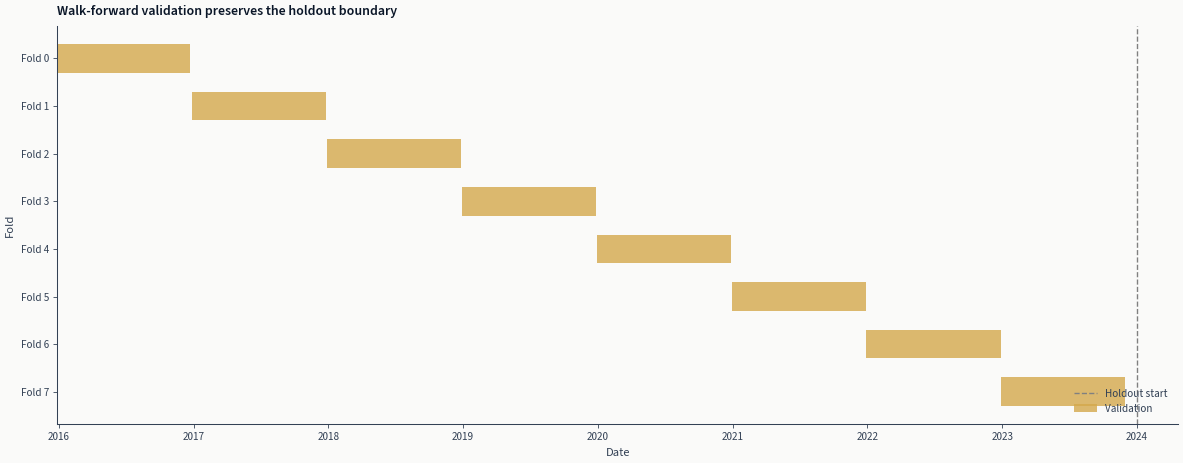

In [8]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(fold_ranges, n_splits, holdout_start)

Each fold trains on a fixed 10-year rolling window and validates on the
year that follows it. The folds are numbered chronologically: fold 0
validates the earliest year (2016) and fold 7 the most recent
pre-holdout year (2023), with the 10-year training window sliding
forward accordingly. The holdout period (2024 onwards) is never used for
model selection.

Because the window is a fixed 10 years rather than expanding, every fold
sees the same amount of training data; what differs across folds is the
market regime each validation year falls in (the 2020 COVID shock, the
2022 rate shock). A model that works only in a handful of folds may be
learning regime-specific patterns rather than persistent structure.

## 2. What Was Actually Run?

Before comparing results, we map what is actually comparable. Not all
model families were trained on all labels, and the five modeling
chapters contribute different kinds of evidence: chapters 11 to 13 produce predictive
forecasts, chapter 14 extracts latent structure, and chapter 15 estimates causal effects. One
ranking over all three would be a ranking over three different questions.

In [9]:
# Coverage map: family × label × evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families × Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families × Labels
shape: (10, 6)
┌─────────┬────────────────┬─────────────┬────────────┬───────────┬──────────┐
│ chapter ┆ family         ┆ label       ┆ evidence   ┆ n_configs ┆ best_ic  │
│ ---     ┆ ---            ┆ ---         ┆ ---        ┆ ---       ┆ ---      │
│ str     ┆ str            ┆ str         ┆ str        ┆ u32       ┆ f64      │
╞═════════╪════════════════╪═════════════╪════════════╪═══════════╪══════════╡
│ Ch13    ┆ deep_learning  ┆ fwd_ret_21d ┆ predictive ┆ 3         ┆ 0.035161 │
│ Ch13    ┆ deep_learning  ┆ fwd_ret_5d  ┆ predictive ┆ 2         ┆ 0.024665 │
│ Ch12    ┆ gbm            ┆ fwd_ret_21d ┆ predictive ┆ 15        ┆ 0.054657 │
│ Ch12    ┆ gbm            ┆ fwd_ret_5d  ┆ predictive ┆ 15        ┆ 0.03341  │
│ Ch14    ┆ latent_factors ┆ fwd_ret_21d ┆ structural ┆ 5         ┆ 0.088949 │
│ Ch14    ┆ latent_factors ┆ fwd_ret_5d  ┆ structural ┆ 5         ┆ 0.048847 │
│ Ch11    ┆ linear         ┆ fwd_ret_21d ┆ predictive ┆ 22        ┆ 0.043668 │
│ Ch1

In [10]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
causal_families = primary_coverage.filter(pl.col("evidence") == "causal")["family"].to_list()
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_21d):
  Predictive families: ['deep_learning', 'gbm', 'linear', 'tabular_dl']
  Structural families: ['latent_factors']
  Causal families: none

All labels trained: ['fwd_ret_21d', 'fwd_ret_5d']


The coverage map is the first result, before any comparison. It says which families were fitted
on which label, and it is read rather than asserted because a family that was never fitted and a
family that was fitted and did nothing look identical in a table of results.

The three evidence types are not three grades of the same thing. **Predictive** families forecast
the return from the feature row and are compared on how well they order the cross-section.
**Structural** ones estimate a low-dimensional factor structure and produce a forecast as a
consequence; they are compared with the predictive families on IC because that is the quantity a
strategy uses, but the object they estimate is different. **Causal** evidence answers a question
about the world rather than about a ranking and is reported in section 7, outside the comparison.
One ranking over all three would be a ranking over three different questions.

Two labels are declared - `fwd_ret_21d` at the monthly rebalancing horizon and `fwd_ret_5d` at
the weekly one - and the coverage above shows they are not equally covered. Every cross-family
comparison in this notebook uses the primary label unless it says otherwise; section 6 is where
the two horizons are read against each other.

## 3. What each family's leading configuration achieved

The comparison starts from a baseline rather than from the leader. If ordinary least squares on
the feature matrix - the simplest thing anyone would try, with no regularization and no
non-linearity - produces no information coefficient at all, then the elaborate models are being
compared on a problem that has nothing in it, and the right conclusion is about the panel rather
than about them.

In [11]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean"][0]
            std = baseline["ic_std"][0] if baseline["ic_std"][0] is not None else 0
            print(f"Linear baseline ({name}):")
            print(f"  IC mean:  {ic:+.4f}" if ic is not None else "  IC mean:  n/a")
            if std > 0:
                print(f"  IC std:   {std:.4f}")
                t_stat = (ic if ic is not None else 0) / (std / np.sqrt(n_splits))
                print(f"  t-stat:   {t_stat:.1f} (across {n_splits} folds)")
            break

Linear baseline (ols):
  IC mean:  +0.0351
  IC std:   0.0835
  t-stat:   1.2 (across 8 folds)


Only full-coverage configurations are shown. One that degenerates to a constant prediction on
some folds has an undefined daily IC there and a short `ic_n_days`, so its average is taken over
fewer folds than the others and is not the same quantity.

In [12]:
_full_days = all_metrics["ic_n_days"].max()
forest_df = (
    all_metrics.filter(
        pl.col("ic_mean_daily").is_not_null(),
        pl.col("ic_n_days") == _full_days,
    )
    .sort("ic_mean_daily", descending=True, nulls_last=True)
    .group_by("family")
    .first()
    .sort("ic_mean_daily", descending=True, nulls_last=True)
    .select(
        "family",
        "config_name",
        "ic_mean_daily",
        "ic_ci_lo",
        "ic_ci_hi",
        "ic_t_hac",
        "ic_n_days",
    )
)
print("Validation IC with HAC 95% CI (highest-IC config per family):")
print(
    forest_df.select(
        "family",
        "config_name",
        pl.col("ic_mean_daily").round(4).alias("ic"),
        pl.col("ic_ci_lo").round(4).alias("ci_lo"),
        pl.col("ic_ci_hi").round(4).alias("ci_hi"),
        pl.col("ic_t_hac").round(2).alias("t_hac"),
        pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
    )
)

Validation IC with HAC 95% CI (highest-IC config per family):
shape: (5, 7)
┌────────────────┬──────────────────┬────────┬─────────┬────────┬───────┬────────┐
│ family         ┆ config_name      ┆ ic     ┆ ci_lo   ┆ ci_hi  ┆ t_hac ┆ n_days │
│ ---            ┆ ---              ┆ ---    ┆ ---     ┆ ---    ┆ ---   ┆ ---    │
│ str            ┆ str              ┆ f64    ┆ f64     ┆ f64    ┆ f64   ┆ i64    │
╞════════════════╪══════════════════╪════════╪═════════╪════════╪═══════╪════════╡
│ latent_factors ┆ cae              ┆ 0.0889 ┆ 0.0386  ┆ 0.1393 ┆ 3.47  ┆ 1995   │
│ gbm            ┆ leaves_7_huber   ┆ 0.0547 ┆ 0.0137  ┆ 0.0956 ┆ 2.61  ┆ 1995   │
│ linear         ┆ ridge_a1000000.0 ┆ 0.0437 ┆ -0.0035 ┆ 0.0909 ┆ 1.81  ┆ 1995   │
│ deep_learning  ┆ tsmixer          ┆ 0.0352 ┆ -0.0005 ┆ 0.0708 ┆ 1.93  ┆ 1995   │
│ tabular_dl     ┆ tabm_l           ┆ 0.0152 ┆ -0.0231 ┆ 0.0535 ┆ 0.78  ┆ 1995   │
└────────────────┴──────────────────┴────────┴─────────┴────────┴───────┴────────┘


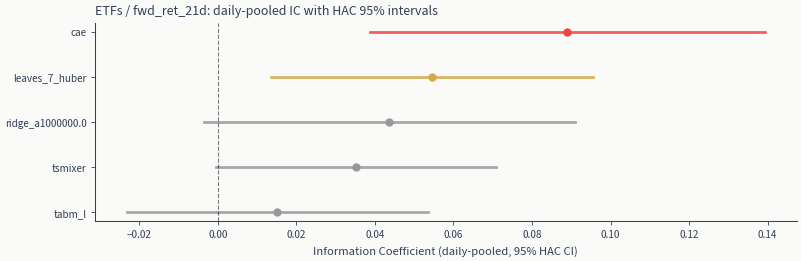

In [13]:
forest_fig = headline_forest_plot(
    forest_df,
    ic_col="ic_mean_daily",
    ci_lo_col="ic_ci_lo",
    ci_hi_col="ic_ci_hi",
    label_col="config_name",
    family_col="family",
    title=f"ETFs / {PRIMARY_LABEL}: daily-pooled IC with HAC 95% intervals",
)
_ic = forest_df["ic_mean_daily"]
show_with_alt(
    forest_fig,
    "Forest plot of each model family's highest daily-pooled information coefficient with its "
    "HAC 95% confidence interval, one row per family. Counted from the frame: "
    f"{forest_df.height} families, IC from {_ic.min():+.4f} to {_ic.max():+.4f}, "
    f"{int((forest_df['ic_ci_lo'] > 0).sum())} with an interval entirely above zero.",
)

**The interval is the result; the point estimate is a summary of it.** Each row above is one
family's highest-IC configuration with a Driscoll-Kraay ninety-five percent interval around it,
taken that way because these ICs are daily correlations on an overlapping label, so consecutive
days are dependent and an ordinary standard error would be far too small.

Three things to read off it, in order:

- **Which intervals exclude zero.** Those are the families this panel supports a claim about.
  A family whose interval crosses zero is directionally positive and not distinguishable from
  having no signal, whatever its rank in the table.
- **Which intervals overlap each other.** Where two overlap heavily, the ordering between them is
  not something the data decided, and reading a table sorted by point estimate as a ranking puts
  a claim on that ordering the interval does not support.
- **Whether any family stands clear of the others.** One that does is the panel's strongest
  single piece of evidence and is worth asking what it does differently. Section 7 is where the
  latent-factor members are separated by exactly that question.

**Only full-coverage configurations appear.** A configuration that degenerates to a constant
prediction on some folds - a heavily L1-penalised linear model whose coefficients all reach zero
is the usual case - has an undefined daily IC on those folds, so its average is taken over fewer
of them. Ranking it against one measured on all of them compares two different quantities, so it
is excluded rather than shown with a footnote.

### Fold by fold, not on average

The comparison below takes each family's leading configuration and looks at what it did in every
fold rather than at the average over them. A configuration whose highest average IC comes from
one or two exceptional windows is not the more credible choice, and the average alone cannot say
which case it is.

In [14]:
# Build fold × family IC matrix from raw predictions
fold_ic = (
    fold_performance_matrix(best_preds, date_col=DATE_COL)
    if best_preds.height > 0
    else pl.DataFrame()
)

### Fold by family, with the uncertain cells muted

A cell is muted where the within-fold information coefficient is not credibly different from zero
- a two-sided normal approximation on the fold's own IC against its within-fold dispersion, at
the five percent level. What is left in colour is where the IC is large relative to how much it
varied inside that fold, which is not the same set of cells as where the mean IC was highest.

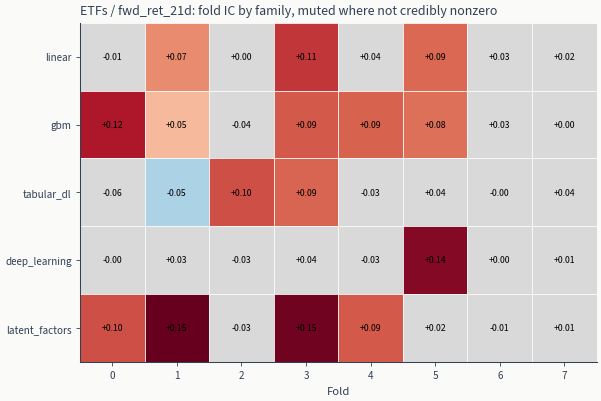

In [15]:
fold_heatmap_fig = fold_heatmap_with_ci(
    CASE_STUDY,
    label=PRIMARY_LABEL,
    title=f"ETFs / {PRIMARY_LABEL}: fold IC by family, muted where not credibly nonzero",
)
show_with_alt(
    fold_heatmap_fig,
    "Heatmap of the within-fold information coefficient, one row per model family and one column "
    "per walk-forward fold, with cells muted to grey where the within-fold IC is not credibly "
    "different from zero at the five percent level.",
)

In [16]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (5, 8)
┌──────────────┬──────────┬───────────┬──────────┬────────────┬───────────┬──────────────┬─────────┐
│ model_label  ┆ mean_ic  ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positive ┆ n_folds │
│ ---          ┆ ---      ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ ---          ┆ ---     │
│ str          ┆ f64      ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ f64          ┆ u32     │
╞══════════════╪══════════╪═══════════╪══════════╪════════════╪═══════════╪══════════════╪═════════╡
│ latent_facto ┆ 0.088202 ┆ 0.112688  ┆ 0.103358 ┆ -0.077575  ┆ 0.200123  ┆ 0.75         ┆ 8       │
│ rs/cae       ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ gbm/leaves_7 ┆ 0.054137 ┆ 0.066248  ┆ 0.05358  ┆ -0.040839  ┆ 0.122145  ┆ 0.875        ┆ 8       │
│ _huber       ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ linear/ridge ┆ 0.043417 ┆ 0.033715  ┆ 0.040993 

**The heatmap answers a question the average cannot.** A family's mean IC is compatible with two
very different pictures: a modest positive result repeated in every fold, or a large one in two
folds and nothing in the rest. The first is a property of the panel; the second is a property of
two years. Reading across a row tells you which.

The muting is what keeps that reading honest. A cell is greyed when its within-fold IC is not
credibly different from zero given the dispersion inside that fold, so a row that looks warm on
average but is mostly grey is a row whose average is carried by the few cells that are not.

The per-family table beneath it puts numbers on the same thing: `pct_positive` is how often the
family was on the right side, `worst_fold` is what it did in its worst year, and the gap between
`mean_ic` and `median_ic` says whether the average is being pulled by one fold.

## 4. Stability over time

A mean IC carried by two exceptional windows and a mean IC repeated in every window are the same
number describing two different things. For a strategy that runs for years and cannot choose
which regime it meets, the second is what can be sized and the first is a bet on the calendar.
This section separates them.

### The spread of each family's fold results

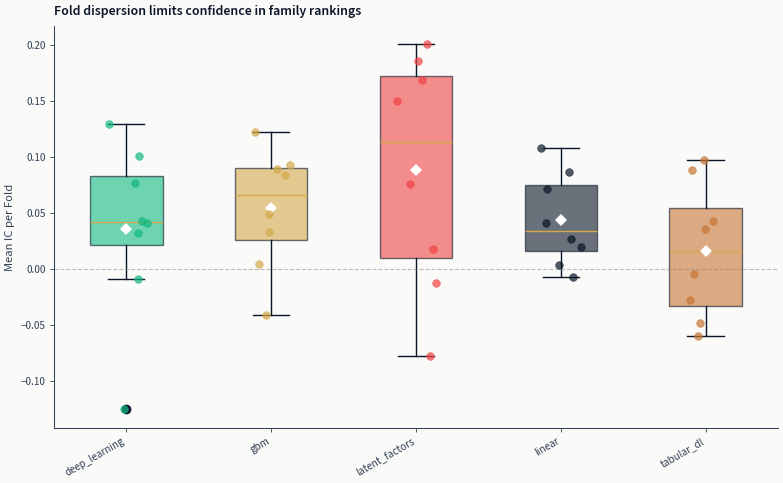

In [17]:
plot_fold_boxplot(fold_ic)

The box plots put each family's eight fold ICs on one axis. The box is the interquartile range,
so a narrow one is a family that says roughly the same thing in every window, and the lower
whisker is the year that would have been hardest to hold through.

**For a strategy that has to be deployed before its regime is known, the lower whisker is the
number that decides.** A family with a high average and a bad worst fold is offering a bet on
which years arrive. A family with a modest average and a tight box is offering the same thing
every year, which is the thing that can actually be sized. Neither is better in the abstract, and
the reason to look at both is that the mean IC alone hides the distinction completely.

## 5. What Are the Models Learning?

Beyond aggregate IC, we examine the *structure* of predictions. Two
diagnostic questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized returns? A monotonic relationship confirms ranking ability.
2. **Diversity**: do different model families produce similar or
   different rankings? Low correlation between families means ensemble
   value; high correlation means diminishing returns from complexity.

In [18]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity

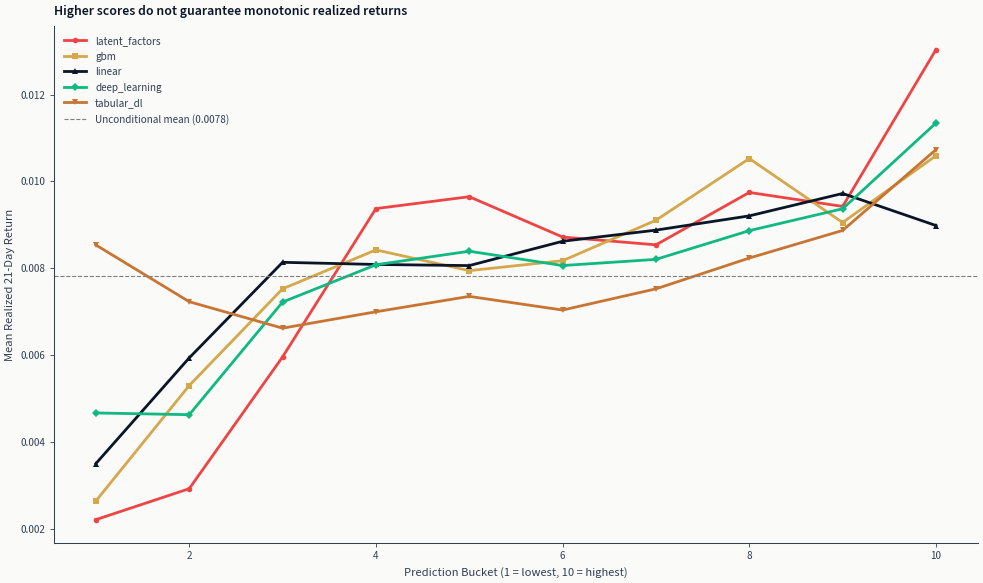


Top-bottom bucket spread vs trading costs (5–15 bps per leg):
  latent_factors        spread=+108 bps  edge/cost=10.8–3.6x
  gbm                   spread=+79 bps  edge/cost=7.9–2.6x
  linear                spread=+55 bps  edge/cost=5.5–1.8x
  deep_learning         spread=+67 bps  edge/cost=6.7–2.2x
  tabular_dl            spread=+22 bps  edge/cost=2.2–0.7x


In [19]:
plot_bucket_monotonicity(
    bucket_results,
    N_BUCKETS,
    unconditional_mean=best_preds["y_true"].mean() if best_preds.height > 0 else None,
    label_name="21-Day Return",
    cost_range=COST_RANGE_BPS,
)

The monotonicity plot confirms genuine ranking ability across model
families. The top-bottom bucket spreads and edge-to-cost ratios are
computed above for each family. The practical implication: a top-N
selection strategy with this signal needs to favor the liquid end
of the ETF universe: the largest funds have costs
of 2–5 bps per leg, while thematic and country ETFs cost 10–20 bps.
Trading costs will consume the edge unless the portfolio tilts
toward the more liquid instruments.

In [20]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)

### Figure 5: Prediction Correlation Across Models

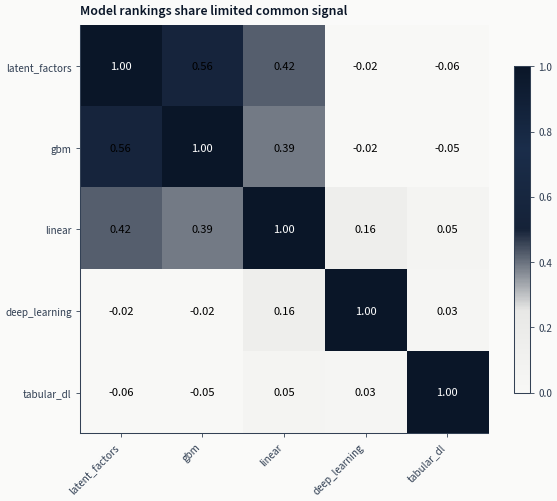


Average pairwise correlation: 0.14
Range: -0.06 to 0.56


In [21]:
plot_correlation_matrix(corr_matrix, corr_labels)

**A correlation matrix over predictions answers whether the families are doing different work.**
Two models that produce nearly the same ranking are one model with two implementations, whatever
their architectures: combining them adds nothing and the simpler of the two is the one to keep.
Two that produce weakly related rankings are disagreeing about something, and a combination of
them can be better than either.

The matrix is the input to that decision rather than the decision. Ensembling happens in the
synthesis chapter, over families that also survive the signal-stage backtest, and a pair that
disagrees usefully here may still be a pair where one member has nothing.

### How Much Does Additional Model Complexity Help?

For models with checkpoint data, we observe how validation IC evolves
with training. This reveals where diminishing returns begin and
whether models overfit with additional epochs.

In [22]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['gbm', 'latent_factors', 'tabular_dl', 'deep_learning']


### Figure 6: Learning Curves

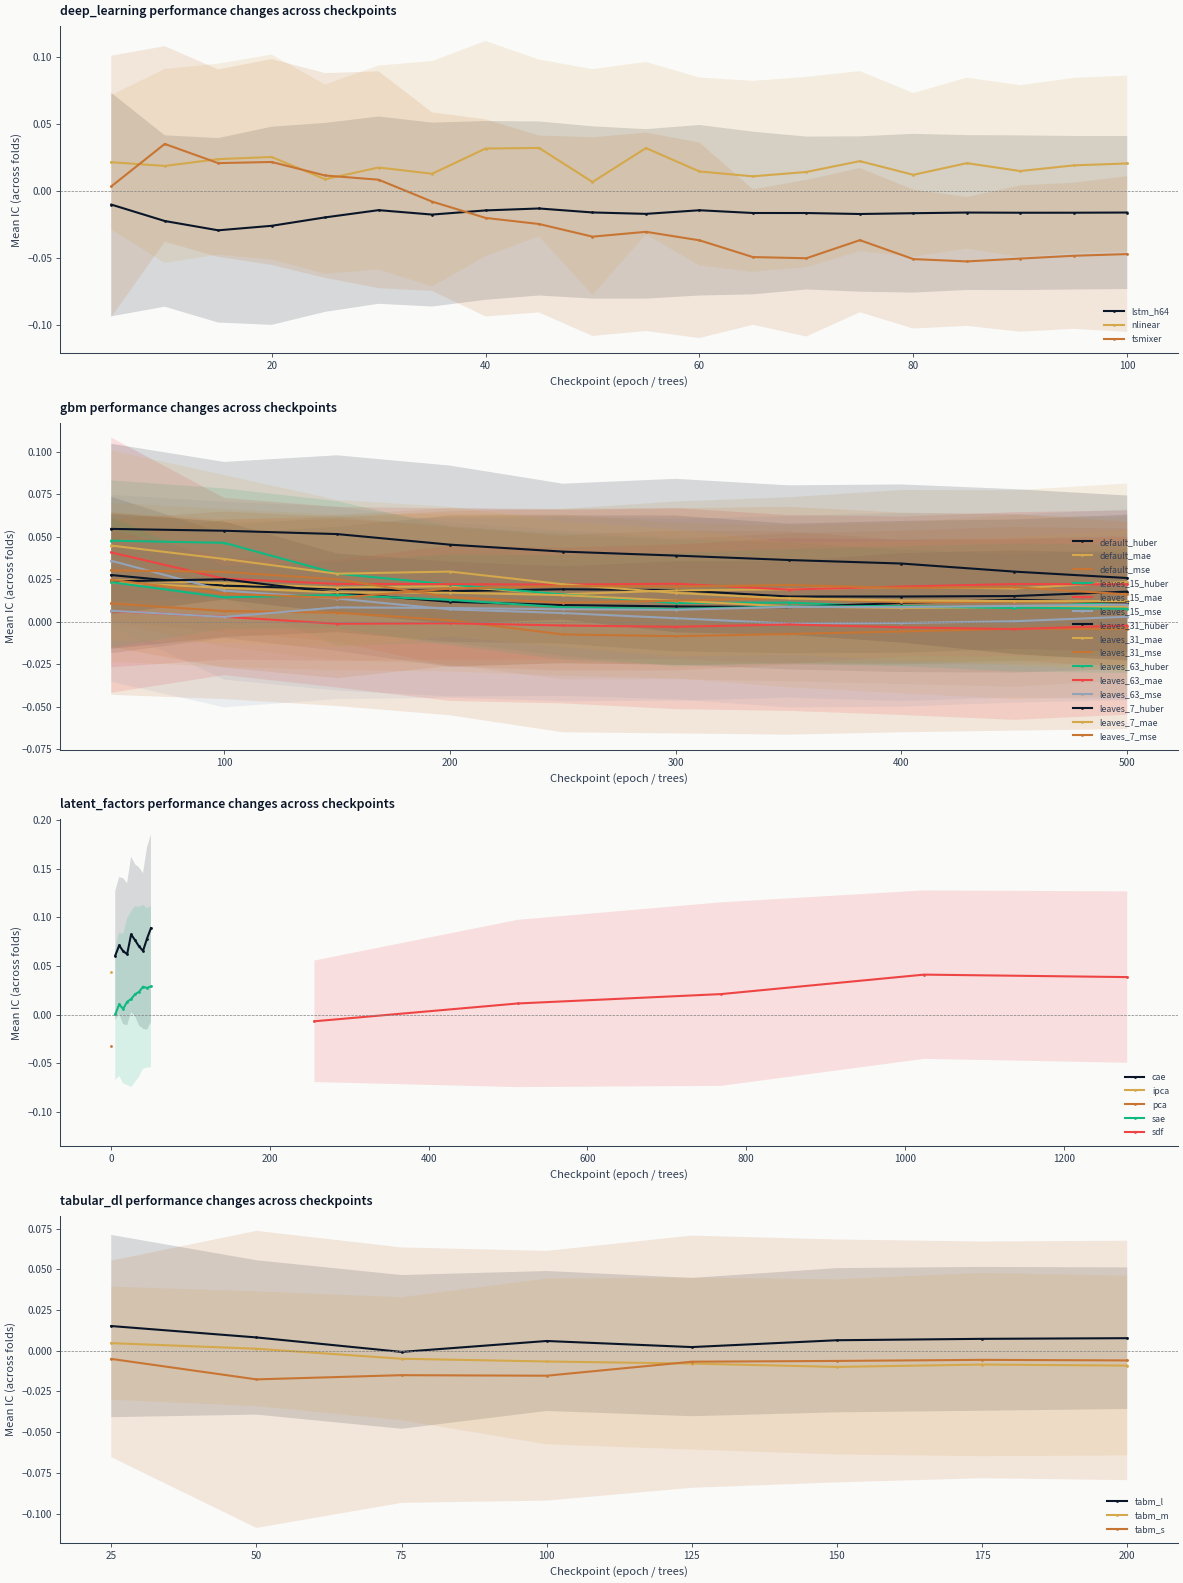

In [23]:
plot_learning_curves(cp_data, cp_families)

**A checkpoint is part of a configuration's identity, not a detail of how it was trained.** Each
point on these curves is a separately registered prediction set with its own hash, so choosing a
checkpoint is choosing a model, and it happens on the same evidence and under the same selection
rule as choosing between architectures.

What the curves are for is the shape. A curve that climbs and then plateaus says the extra
training reached diminishing returns and the choice within the plateau matters little. One that
climbs and then falls says the model started fitting the training window rather than the
structure, and where it turns is the useful reading. One that never leaves zero says the
configuration has nothing, regardless of how long it was trained.

The confidence bands are the reason not to read a peak as a choice: where they are wide relative
to the differences along the curve, the highest checkpoint and its neighbours are not
distinguishable, and picking the argmax is picking noise.

### Which features the forecasts rest on

Feature importance from one fit is an anecdote about one fit. Importance that recurs across every
walk-forward fold is evidence about the panel, and importance that appears in one fold and not
the others is the model finding something local to that window. The heatmap below is arranged to
show the difference: a feature is credible when its row is consistently dark, not when it is
dark somewhere.

In [24]:
# Try GBM booster-based importance first, fall back to feature-prediction correlation
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)

if gbm_importance is None:
    # Fallback: compute feature-prediction IC (correlation between each feature and y_score)
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")

    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]

        # Join best linear model predictions with features
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            # Cast to the prediction frame's own timestamp type rather than to a named unit:
            # Polars refuses a join across two datetime units instead of widening one.
            timestamp_dtype = linear_preds.schema[DATE_COL]
            if features_df.schema[DATE_COL] == pl.String:
                features_df = features_df.with_columns(pl.col(DATE_COL).str.to_datetime())
            if features_df.schema[DATE_COL] != timestamp_dtype:
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(timestamp_dtype))
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

            # Compute correlation of each feature with y_score per fold
            importance_rows = []
            for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
                fold_data = merged.filter(pl.col("fold_id") == fold)
                for feat in feat_cols:
                    vals = fold_data[[feat, "y_score"]].drop_nulls()
                    if vals.height > 50:
                        from scipy.stats import spearmanr

                        corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                        importance_rows.append(
                            {
                                "config_name": "linear",
                                "fold_id": int(fold),
                                "feature": feat,
                                "importance": abs(float(corr)),
                            }
                        )

            if importance_rows:
                gbm_importance = pl.DataFrame(importance_rows)
                # Normalize per fold
                gbm_importance = gbm_importance.with_columns(
                    (
                        pl.col("importance")
                        / pl.col("importance").max().over(["config_name", "fold_id"])
                    ).alias("importance_norm")
                )
                # Filter to top features
                top_features = (
                    gbm_importance.group_by("feature")
                    .agg(pl.col("importance_norm").mean().alias("mean_imp"))
                    .sort("mean_imp", descending=True)
                    .head(TOP_N_FEATURES)["feature"]
                    .to_list()
                )
                gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
                print(
                    f"Computed feature-prediction correlation for {len(top_features)} features across {merged['fold_id'].n_unique()} folds"
                )

if gbm_importance is not None and gbm_importance.height > 0:
    print(
        f"Feature importance: {gbm_importance['feature'].n_unique()} features × {gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("Feature importance data not available.")

No GBM booster files available. Computing feature-prediction correlation as fallback...


Computed feature-prediction correlation for 15 features across 8 folds
Feature importance: 15 features × 8 folds


### Figure 7: Feature Importance Stability Heatmap

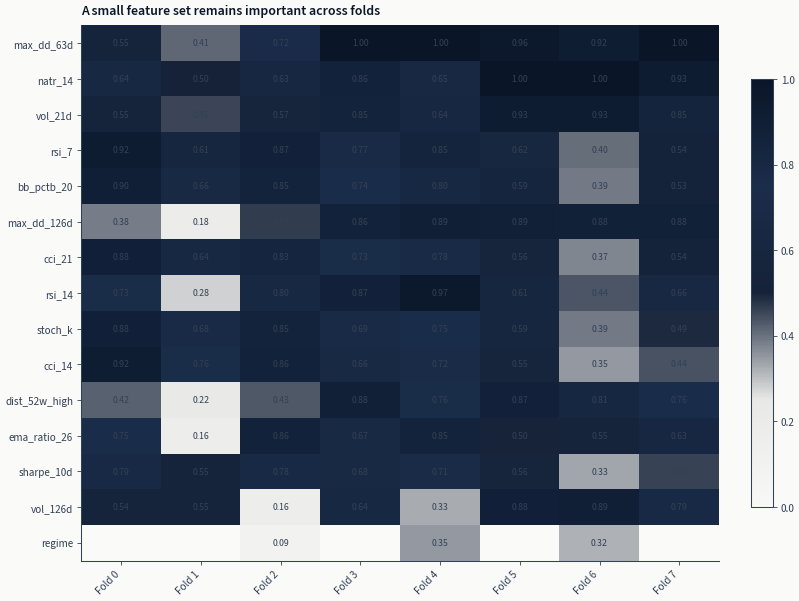

In [25]:
plot_feature_importance_heatmap(gbm_importance, TOP_N_FEATURES)

The feature importance heatmap uses the fallback method (feature-prediction
Spearman correlation) because stored GBM boosters lack named features.
Values are normalized to [0, 1] per fold. Features that appear in the
top 5 across 6+ of 8 folds are credible signal sources; those appearing
only once or twice likely capture regime-specific noise.

The features span momentum at horizons from a week to a year, momentum adjusted for its own
volatility, volatility itself, technical indicators and the yield-curve slope. Where the
fallback method is used, what it measures is how strongly each feature aligns with the linear
model's predictions in that fold, which is not the same as how much the model relied on it -
a feature correlated with one the model uses will score highly without being used at all.

## 6. Heterogeneity: Labels, Horizons, and Regimes

This section answers two questions: does the signal strengthen or
weaken at shorter horizons? And does model ranking depend on the
market regime? Both matter for strategy design.

### The same families at a shorter horizon

Two label horizons are declared: `fwd_ret_21d` at the monthly rebalancing cadence and
`fwd_ret_5d` at the weekly one. The panels below put each family's highest-IC configuration for
each horizon side by side with its HAC interval, and a tile marked "no run" is a family that was
never fitted at that horizon rather than one that was fitted and produced nothing.

Two questions come out of the comparison: whether the cross-sectional signal is stronger at one
horizon than the other, and whether the ordering among families is the same at both. A family
that leads at one horizon and not at the other is a family whose advantage is about the horizon
rather than about the model.

In [26]:
multi_rows = []
for lbl in [PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL]:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    # Full-coverage guard (see forest_df above): exclude configs whose daily IC is
    # defined on only a subset of folds so a family's per-horizon leader is a
    # full-coverage estimator, not a partial-coverage outlier.
    _lbl_full = lbl_metrics["ic_n_days"].max()
    lbl_metrics = lbl_metrics.filter(pl.col("ic_n_days") == _lbl_full)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_21d""","""gbm""","""leaves_7_huber""",0.054657,0.013665,0.095649,2.614926
"""fwd_ret_21d""","""latent_factors""","""cae""",0.088949,0.038633,0.139265,3.46694
"""fwd_ret_21d""","""deep_learning""","""tsmixer""",0.035161,-0.000478,0.070801,1.93485
"""fwd_ret_21d""","""linear""","""ridge_a1000000.0""",0.043668,-0.003519,0.090854,1.814916
"""fwd_ret_21d""","""tabular_dl""","""tabm_l""",0.015176,-0.023132,0.053484,0.776942
"""fwd_ret_5d""","""gbm""","""leaves_7_huber""",0.03341,0.00936,0.057459,2.724377
"""fwd_ret_5d""","""tabular_dl""","""tabm_m""",0.015442,-0.005567,0.036451,1.441482
"""fwd_ret_5d""","""deep_learning""","""nlinear""",0.024665,0.002504,0.046827,2.182705
"""fwd_ret_5d""","""latent_factors""","""cae""",0.048847,0.017987,0.079707,3.104214


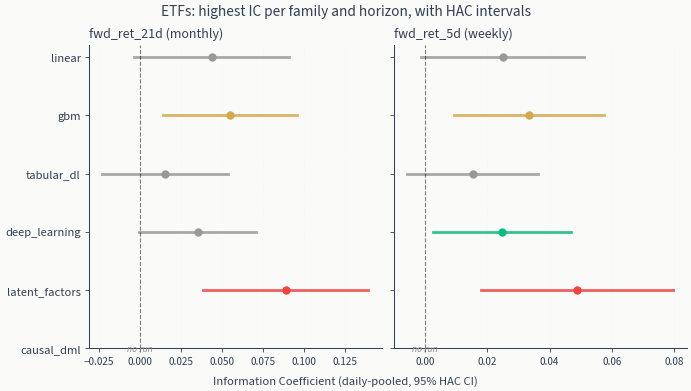

In [27]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=[PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL],
    label_display={
        "fwd_ret_21d": "fwd_ret_21d (monthly)",
        "fwd_ret_5d": "fwd_ret_5d (weekly)",
    },
    title="ETFs: highest IC per family and horizon, with HAC intervals",
)

**Coverage is the first thing the panel above says, before any comparison.** A family with no
tile at a horizon was never fitted there, which is a fact about what was run rather than a result
about the horizon - and reading an absence as a weak result is the mistake this layout exists to
prevent.

Where a family spans both horizons, the comparison is worth making carefully, because the two
panels do not have the same amount of evidence behind them. A five-day label produces more
scoreable validation dates than a twenty-one-day one over the same window, so its intervals are
tighter for reasons that have nothing to do with signal. A family that looks more credible at the
shorter horizon may simply have been measured more times there, and the point estimates are what
to compare on strength while the intervals are what to compare on confidence.

### Regime Conditioning

Models do not have one universal performance level. The ETF cross-section
is driven by macro regimes: risk-on/risk-off rotations, volatility spikes,
and trend reversals can all shift which model family extracts signal. We
condition performance on a volatility regime derived from cross-sectional
return dispersion, which is a usable proxy for macro uncertainty.

In [28]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

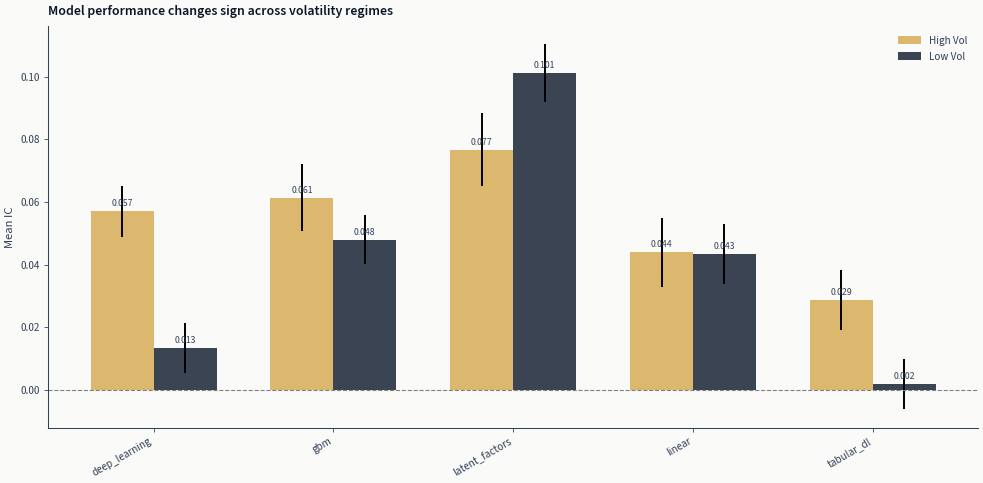

In [29]:
plot_regime_bars(regime_df)

Regime sensitivity is critical for ETF rotation strategies because the
universe itself is a macro instrument. During high-volatility periods
(risk-off), the cross-section separates more sharply, with bonds rallying
while commodities and emerging markets sell off, creating larger
cross-sectional spreads for models to exploit. During low-volatility
periods (risk-on), ETF returns converge, and cross-sectional
dispersion shrinks, making ranking harder.

If one model family achieves the highest IC in high-vol but fails in
low-vol, a regime-conditional strategy that switches models (or adjusts
position sizing) based on realized volatility may produce a higher
net IC than a static choice.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

ETFs is one of the five case studies in scope for the latent-factor
pipeline. Five estimators were fitted on this cross-section: principal components, instrumented
PCA, the conditional autoencoder, the stochastic discount factor and the supervised
autoencoder. [`11_latent_factors`](11_latent_factors.ipynb) sets out what separates them. The
diagnostics below read each one's persisted fold extras to look inside the fit rather than at
its score.

The per-fold diagnostics are stored under the **training hash** of the run that produced them -
`run_log/training/<training_hash>/fold_extras.json` - so the configuration name from the metrics
table has to be resolved to that hash first. Passing the name straight through returns `None` for
every estimator, and because the loader answers `None` for "no file" rather than raising, the
figures below silently render nothing while the prose beside them describes what they show. The
estimators that wrote no extras are named rather than left out, so an empty panel is
distinguishable from a panel that was never asked for.

In [30]:
lf_runs = (
    all_labels_metrics.filter(
        pl.col("family") == "latent_factors", pl.col("label") == PRIMARY_LABEL
    )
    .sort("ic_mean_daily", descending=True, nulls_last=True)
    .group_by("config_name", maintain_order=True)
    .first()
    .select("config_name", "training_hash", "ic_mean_daily")
)
lf_extras = {}
for _row in lf_runs.iter_rows(named=True):
    _extras = load_fold_extras(CASE_STUDY, _row["training_hash"])
    if _extras:
        lf_extras[_row["config_name"]] = _extras
_missing_extras = sorted(set(lf_runs["config_name"]) - set(lf_extras))
if _missing_extras:
    print(f"no fold_extras.json written by: {', '.join(_missing_extras)}")

# Print IC summary from registry
lf_metrics = all_labels_metrics.filter(
    pl.col("family") == "latent_factors", pl.col("label") == PRIMARY_LABEL
)
if lf_metrics.height > 0:
    lf_best = (
        lf_metrics.group_by("config_name")
        .agg(ic=pl.col("ic_mean").max())
        .sort("ic", descending=True)
    )
    print(f"Latent factor IC on {PRIMARY_LABEL}:")
    for row in lf_best.iter_rows(named=True):
        ic_text = f"{row['ic']:+.4f}" if row["ic"] is not None else "n/a"
        print(f"  {row['config_name']:6s}: {ic_text}")

print(f"\nFold extras available: {list(lf_extras.keys())}")

Latent factor IC on fwd_ret_21d:
  cae   : +0.0889
  ipca  : +0.0443
  sdf   : +0.0411
  sae   : +0.0290
  pca   : -0.0321

Fold extras available: ['cae', 'ipca', 'sdf', 'sae', 'pca']


#### How concentrated is the return panel's variance?

PCA's loadings come from the covariance of the training returns, so how much of that covariance
the leading components carry decides how much structure there is to load on. A steep drop after
one or two components means the panel is dominated by a few common movements; a flat profile
means the variance is spread thinly and a low-rank model has little to work with.

Both panels average over the folds, because each fold refits the decomposition on its own
training window and a single fold's profile is one draw of it.

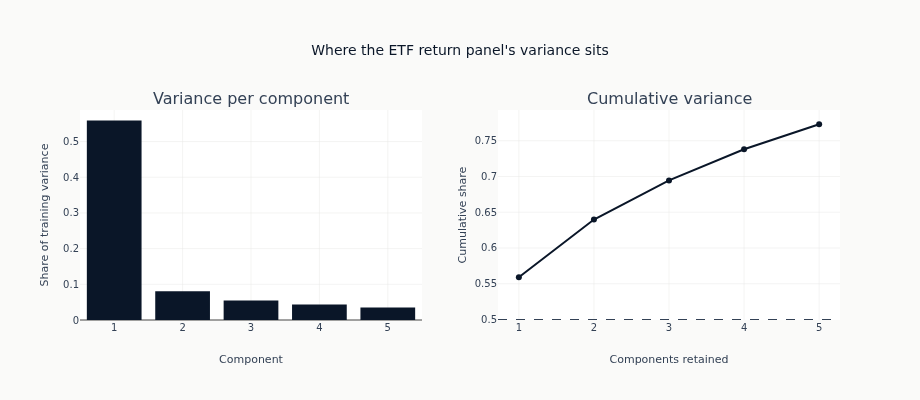

In [31]:
if "pca" not in lf_extras:
    print("PCA fold extras are not available, so the decomposition cannot be read back")
else:
    var_ratios = [e["explained_variance_ratio"] for e in lf_extras["pca"]]
    mean_var = np.asarray(np.mean(var_ratios, axis=0))
    components = list(range(1, len(mean_var) + 1))
    cumulative = np.cumsum(mean_var)

    scree = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("Variance per component", "Cumulative variance"),
    )
    scree.add_trace(
        go.Bar(x=components, y=mean_var.tolist(), marker_color=COLORS["blue"], showlegend=False),
        row=1,
        col=1,
    )
    scree.add_trace(
        go.Scatter(
            x=components,
            y=cumulative.tolist(),
            mode="lines+markers",
            line=dict(color=COLORS["blue"]),
            showlegend=False,
        ),
        row=1,
        col=2,
    )
    scree.add_hline(
        y=0.5, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=1, col=2
    )
    scree.update_xaxes(title_text="Component", row=1, col=1)
    scree.update_xaxes(title_text="Components retained", row=1, col=2)
    scree.update_yaxes(title_text="Share of training variance", row=1, col=1)
    scree.update_yaxes(title_text="Cumulative share", row=1, col=2)
    scree.update_layout(
        title="Where the ETF return panel's variance sits",
        height=400,
        width=920,
        margin=dict(t=110),
    )
    show_plotly_with_alt(
        scree,
        "Two side-by-side charts of the ETF return panel's principal-component variance, averaged "
        "across walk-forward folds: a bar chart of the share each component carries, and a line "
        "chart of the cumulative share with a dashed line at half. Counted from the array: "
        f"{len(mean_var)} components, the leading one carrying {mean_var[0]:.1%}, "
        f"the whole set {cumulative[-1]:.1%}.",
    )

**What the decomposition does and does not settle.** A concentrated variance profile says the
funds move together, which is what makes a factor model the right shape for this panel. It says
nothing about whether those factors carry a **premium** - whether loading on them is rewarded.
That is a separate question, and it is the one the latent-factor IC table above answers.

The estimators in that table differ in exactly one thing: how much the fit is allowed to know
about returns. PCA reads the return panel alone; IPCA lets the features set the exposures; the
conditional autoencoder does the same with a network in place of a linear map; the stochastic
discount factor and the supervised autoencoder each drop the two-stage split, one by pricing the
cross-section directly and one by predicting the return directly. Where the ordering in the table
sorts them by that axis rather than by model complexity, the panel is telling you that what
helps is supervision, not capacity. [`11_latent_factors`](11_latent_factors.ipynb) sets out the
family, and each member's own notebook reports its fit.

#### Did the autoencoders converge, and did they converge to the same place?

One line per fold, per model. What matters is not the level - the loss scales with the fold's own
training window - but the shape: a curve that descends and flattens has converged, and a set of
curves that flatten at similar rates is a model finding reproducible structure. Curves that
diverge from each other say the representation is a property of the fold rather than of the
panel, which is a reason to distrust it downstream whatever its IC.

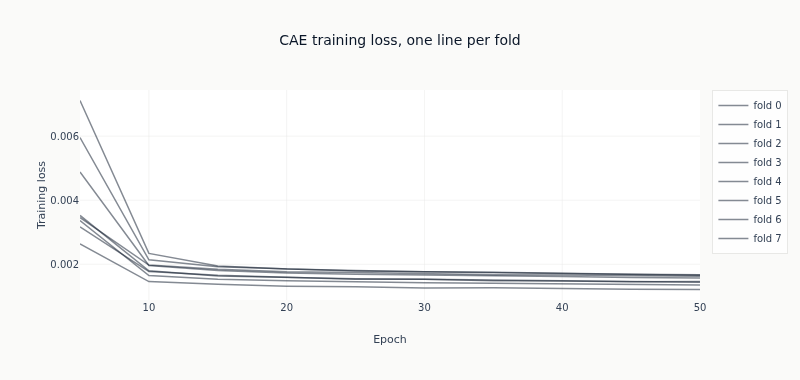

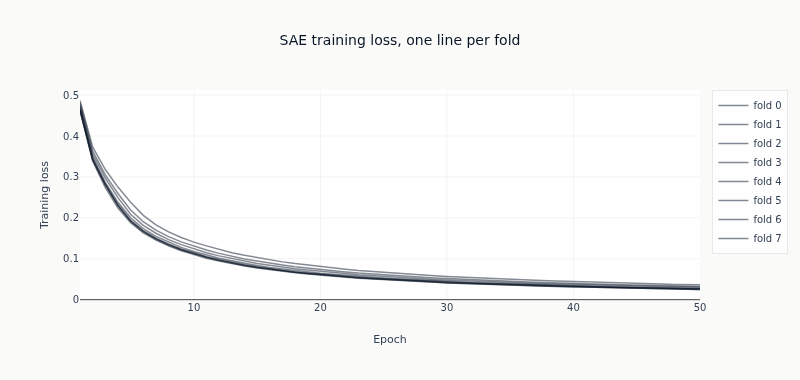

In [32]:
for model_name in ("cae", "sae"):
    if model_name not in lf_extras:
        print(f"{model_name.upper()} fold extras are not available")
        continue
    curves = []
    for fold_index, fold in enumerate(lf_extras[model_name]):
        history = [h for h in fold.get("train_history", []) if "train_loss" in h]
        if history:
            curves.append(
                (fold_index, [h["epoch"] for h in history], [h["train_loss"] for h in history])
            )
    if not curves:
        print(f"{model_name.upper()} fold extras carry no training history")
        continue

    loss_fig = go.Figure()
    for fold_index, epochs, losses in curves:
        loss_fig.add_trace(
            go.Scatter(
                x=epochs,
                y=losses,
                mode="lines",
                name=f"fold {fold_index}",
                line=dict(color=COLORS["blue"], width=1.5),
                opacity=0.5,
            )
        )
    loss_fig.update_xaxes(title_text="Epoch")
    loss_fig.update_yaxes(title_text="Training loss")
    loss_fig.update_layout(
        title=f"{model_name.upper()} training loss, one line per fold",
        height=380,
        width=800,
        margin=dict(t=90),
    )
    _finals = [losses[-1] for _, _, losses in curves]
    show_plotly_with_alt(
        loss_fig,
        f"Line chart of the {model_name.upper()} autoencoder's training loss against epoch, one "
        "line per walk-forward fold. Counted from the histories: "
        f"{len(curves)} folds over up to {max(len(e) for _, e, _ in curves)} epochs, "
        f"final loss from {min(_finals):.4g} to {max(_finals):.4g}.",
    )

### Causal DML (Ch15)

[`12_causal_dml`](12_causal_dml.ipynb) writes to `causal_runs` rather than to
`prediction_metrics`, because what it registers is not a forecast. It answers what would happen
to a fund's next return if its momentum were different, holding the declared confounders fixed -
a question about the world, not about a ranking. It has no prediction set, enters no population,
and is not a candidate for [`14_backtest`](14_backtest.ipynb).

The row is resolved by label rather than read out of the table by position. A label resolves to
exactly one **current** causal identity, and a registry holding two undeclared ones raises rather
than picking the first - which is the difference between reading a result and reading a row that
happens to be there.

The refutation p-value is nullable by contract: fewer than ten successful placebo draws leaves it
NULL, and the classification derived from it None, because a p-value from that few draws cannot
reject at any threshold. The cell prints "not run" rather than formatting a missing number, which would
fail after half the block had already printed.

In [33]:
causal_study = study
try:
    causal = CausalResult.one(causal_study, label=PRIMARY_LABEL)
except ValueError as error:
    causal = None
    print(f"No resolvable causal result for {PRIMARY_LABEL}: {error}")

if causal is not None:
    estimand = causal.spec["computation"]["estimand"]
    metrics = causal.metrics
    interval = 1.96 * metrics["dml_se_hac"]
    print(f"Causal DML on {PRIMARY_LABEL}, identity {causal.hash}")
    print(f"  Treatment:        {estimand['treatment']}")
    print(f"  Confounders:      {', '.join(estimand['confounders'])}")
    print(f"  Observations:     {metrics['n_obs']:,}")
    print(
        f"  Adjusted effect:  {metrics['dml_effect']:+.4f} "
        f"(Driscoll-Kraay SE {metrics['dml_se_hac']:.4f}, "
        f"95% interval {metrics['dml_effect'] - interval:+.4f} to "
        f"{metrics['dml_effect'] + interval:+.4f}, p {metrics['p_value_hac']:.4f})"
    )
    print(f"  Unadjusted (OLS): {metrics['naive_effect']:+.4f}")
    # NULL when fewer than ten placebo draws succeed; see the note above the cell.
    refutation_p = metrics["refutation_p"]
    print(
        f"  Refutation:       {metrics['refutation_class'] or 'not run'}"
        + ("" if refutation_p is None else f" (p {refutation_p:.4f})")
    )

Causal DML on fwd_ret_21d, identity aa9ef9f7264a
  Treatment:        skip_recent_6_1
  Confounders:      vol_21d, vol_126d, regime, yield_curve_slope
  Observations:     312,010
  Adjusted effect:  -0.0194 (Driscoll-Kraay SE 0.0145, 95% interval -0.0478 to +0.0090, p 0.1796)
  Unadjusted (OLS): -0.0093
  Refutation:       Fails (p 0.1782)


**The causal estimate and the predictive IC answer different questions, and neither settles the
other.** A positive information coefficient says the model orders the cross-section usefully. The
causal estimate says how much of the momentum-return association is left once volatility, regime
and the yield-curve slope are accounted for. A strategy that goes long the top of a ranking and
short the bottom needs the first and does not need the second, which is why nothing here feeds
selection.

What the causal row does carry is a warning about **interpretation**. If the adjusted effect
above is small relative to its standard error, or sits on the opposite side of zero from the
unadjusted one, then the momentum feature is not a directional bet the data support - whatever
the predictive families are extracting from it, "high momentum causes high returns" is not the
mechanism, and describing the strategy that way would be describing something the estimate does
not show. [`12_causal_dml`](12_causal_dml.ipynb) sets out why the Driscoll-Kraay interval and the
block-permutation p-value can disagree, and which one to believe when they do.

### Calibration: Are Prediction Intervals Honest?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated. The
width measured here is the one the `conformal_weighted` allocator sizes
positions with: calibrated per symbol on every absolute residual known at
`t - h`, where `h` is this label's horizon in data steps, falling back to a
quantile pooled over every symbol where one has too few residuals of its
own. A decision is covered when its absolute residual falls inside that
half-width, and `n_uncalibrated` counts the decisions that cleared no
warm-up and that no coverage figure describes.

Empirical coverage materially below the nominal level signals overconfident
residual scaling - the model is more wrong, more often, than its
training-time spread suggests. Width is reported as a fraction of the
standard deviation of the outcomes it was measured against, so families with
different return scales are comparable; smaller width at matched coverage
means tighter, more useful intervals.

Read it as a diagnostic of residual dispersion rather than a guarantee.
Split conformal's finite-sample coverage (Vovk et al., 2005; Lei et al.,
2018) requires the calibration and evaluation scores to be exchangeable and
return residuals are not, and nothing in the allocation path reads an
interval or a coverage level - the width stands in for a volatility
estimate. See Ch12 §12.6 / `11_conformal_gbm` for the full conformal toolkit
(CQR, ACI).

Each row is the family's highest-IC configuration for the primary label.
That is a model-level ranking and not the funnel's - every selection stage
ranks on validation backtest Sharpe - and it is used here because this
diagnostic runs before any backtest exists to rank.

In [34]:
conformal_etfs = conformal_coverage_diagnostic(
    CASE_STUDY,
    label=PRIMARY_LABEL,
)
conformal_etfs

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test,n_uncalibrated
str,str,f64,f64,f64,i64,i64
"""deep_learning""","""tsmixer""",0.8,0.740246,1.982543,185791,1856
"""deep_learning""","""tsmixer""",0.9,0.851575,2.627351,185791,1856
"""deep_learning""","""tsmixer""",0.95,0.91907,3.286963,185791,1856
"""gbm""","""leaves_7_huber""",0.8,0.752375,1.842055,186617,1856
"""gbm""","""leaves_7_huber""",0.9,0.859804,2.448235,186617,1856
…,…,…,…,…,…,…
"""linear""","""ridge_a1000000.0""",0.9,0.860474,2.439043,186617,1856
"""linear""","""ridge_a1000000.0""",0.95,0.921358,3.060794,186617,1856
"""tabular_dl""","""tabm_l""",0.8,0.765102,2.256084,186617,1856


In [35]:
if conformal_etfs.height > 0:
    pivot = conformal_etfs.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (5, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ tsmixer    ┆ 0.740246   ┆ 0.851575  ┆ 0.91907   ┆ 1.982543  ┆ 2.627351  ┆ 3.286963  │
│ ing  

Coverage at the three nominal levels tracks the targets reasonably
closely across families, with most highest-IC configs landing within a few
percentage points of nominal. Departures are informative: under-coverage
(empirical < nominal) signals residuals heavier-tailed than the
calibration window suggests, which is a known concern for daily ETF returns
with episodic volatility shocks; over-coverage means intervals are
wider than needed. Width-per-std is the more useful axis for
distinguishing models: at matched coverage, a family whose intervals
are narrower in std-units is producing tighter forecasts of the
residual distribution. This calibration diagnostic feeds Ch19 risk
management, where wider intervals scale down position size, and
ACI extensions (Ch12 §12.6) update interval width online to track
regime shifts in residual variance.

## 8. What this analysis can and cannot settle

Two tables close the notebook. The first is the validation record above, restated in one place.
The second is what happens to that record once the number of configurations tried is taken into
account - and it depends on the signal-stage backtest, which runs in
[`14_backtest`](14_backtest.ipynb) and therefore may not exist yet.

**This notebook does not select anything.** Selection is best validation backtest Sharpe, which
is a quantity no cell here computes. What this notebook produces is the description of the
population that selection will then be made over.

In [36]:
print("Validation IC per family, daily-pooled with HAC 95% intervals:")
print(
    forest_df.select(
        "family",
        "config_name",
        pl.col("ic_mean_daily").round(4).alias("ic"),
        pl.col("ic_ci_lo").round(4).alias("ci_lo"),
        pl.col("ic_ci_hi").round(4).alias("ci_hi"),
        pl.col("ic_t_hac").round(2).alias("t_hac"),
    )
)

Validation IC per family, daily-pooled with HAC 95% intervals:
shape: (5, 6)
┌────────────────┬──────────────────┬────────┬─────────┬────────┬───────┐
│ family         ┆ config_name      ┆ ic     ┆ ci_lo   ┆ ci_hi  ┆ t_hac │
│ ---            ┆ ---              ┆ ---    ┆ ---     ┆ ---    ┆ ---   │
│ str            ┆ str              ┆ f64    ┆ f64     ┆ f64    ┆ f64   │
╞════════════════╪══════════════════╪════════╪═════════╪════════╪═══════╡
│ latent_factors ┆ cae              ┆ 0.0889 ┆ 0.0386  ┆ 0.1393 ┆ 3.47  │
│ gbm            ┆ leaves_7_huber   ┆ 0.0547 ┆ 0.0137  ┆ 0.0956 ┆ 2.61  │
│ linear         ┆ ridge_a1000000.0 ┆ 0.0437 ┆ -0.0035 ┆ 0.0909 ┆ 1.81  │
│ deep_learning  ┆ tsmixer          ┆ 0.0352 ┆ -0.0005 ┆ 0.0708 ┆ 1.93  │
│ tabular_dl     ┆ tabm_l           ┆ 0.0152 ┆ -0.0231 ┆ 0.0535 ┆ 0.78  │
└────────────────┴──────────────────┴────────┴─────────┴────────┴───────┘


### The cost of having searched

A leader chosen from many configurations is partly a leader because many were tried. The
selection-adjusted table below carries the deflated Sharpe, the Sharpe the leader of
`k_variants` zero-skill configurations would be expected to reach, the reality-check p-value and the
probability of backtest overfitting - all computed at the signal stage, over the configurations
actually swept.

It reads `cohort_metrics`, which is computed once the whole pipeline exists and written by
[`20_strategy_analysis`](20_strategy_analysis.ipynb) - the notebook that has every stage in front
of it. So on a first pass this table is empty, and it is empty for a reason worth stating: the
cost of a search cannot be priced until the search has happened. The notebook says so rather than
failing, and filling in on a second pass is the normal course rather than a repair.

In [37]:
sel_adj = selection_adjusted_leader_table(CASE_STUDY, stage="signal")
if sel_adj.is_empty():
    print(
        "No signal-stage cohort metrics are registered, so the selection-adjusted view is empty. "
        "Run 14_backtest and re-run this notebook to fill it."
    )
else:
    print("Selection-adjusted signal-stage leader per family:")
    print(
        sel_adj.select(
            "family",
            "config_name",
            pl.col("sharpe").round(3),
            pl.col("sharpe_ci95_lo").round(3).alias("sh_lo"),
            pl.col("sharpe_ci95_hi").round(3).alias("sh_hi"),
            pl.col("dsr").round(3),
            pl.col("expected_max_sharpe").round(3).alias("exp_max"),
            pl.col("reality_check_pvalue").round(3).alias("rc_p"),
            pl.col("pbo").round(2),
            pl.col("k_variants").cast(pl.Int64).alias("k"),
        )
    )

Selection-adjusted signal-stage leader per family:
shape: (5, 10)
┌────────────────┬──────────────────┬────────┬───────┬───┬─────────┬──────┬──────┬──────┐
│ family         ┆ config_name      ┆ sharpe ┆ sh_lo ┆ … ┆ exp_max ┆ rc_p ┆ pbo  ┆ k    │
│ ---            ┆ ---              ┆ ---    ┆ ---   ┆   ┆ ---     ┆ ---  ┆ ---  ┆ ---  │
│ str            ┆ str              ┆ f64    ┆ f64   ┆   ┆ f64     ┆ f64  ┆ f64  ┆ i64  │
╞════════════════╪══════════════════╪════════╪═══════╪═══╪═════════╪══════╪══════╪══════╡
│ gbm            ┆ leaves_63_huber  ┆ 0.74   ┆ 0.052 ┆ … ┆ 0.004   ┆ null ┆ 0.31 ┆ 447  │
│ latent_factors ┆ cae              ┆ 0.734  ┆ 0.14  ┆ … ┆ 0.004   ┆ null ┆ 0.49 ┆ 66   │
│ deep_learning  ┆ lstm_h64         ┆ 0.702  ┆ 0.154 ┆ … ┆ null    ┆ null ┆ null ┆ null │
│ tabular_dl     ┆ tabm_s           ┆ 0.671  ┆ 0.092 ┆ … ┆ null    ┆ null ┆ null ┆ null │
│ linear         ┆ ridge_a1000000.0 ┆ 0.663  ┆ 0.028 ┆ … ┆ null    ┆ null ┆ null ┆ null │
└────────────────┴────────────────

### Validation against holdout, for whatever has been retrained

The holdout is opened once, for the candidate the selection workflow names, and
[`20_strategy_analysis`](20_strategy_analysis.ipynb) is where that happens. Until it does, the
holdout side of this table is empty by design rather than by omission - a family showing no
holdout figure was never retrained on it, which is not the same as a family that was retrained
and did badly.

The gap between the two sides, where both exist, is the quantity worth reading: a validation
figure is measured on folds that have been looked at many times by the time a case study reaches
this notebook, and a holdout figure has been looked at once.

In [38]:
decay = holdout_decay_table(CASE_STUDY, label=PRIMARY_LABEL)
if decay.is_empty():
    print("No holdout evaluations are registered for this label.")
else:
    print(
        decay.select(
            "family",
            "config_name",
            pl.col("val_ic").round(4),
            pl.col("val_ci_lo").round(4).alias("val_lo"),
            pl.col("val_ci_hi").round(4).alias("val_hi"),
            pl.col("ho_ic").round(4),
            pl.col("ho_ci_lo").round(4).alias("ho_lo"),
            pl.col("ho_ci_hi").round(4).alias("ho_hi"),
            pl.col("decay_pp").round(4).alias("decay"),
        )
    )
    retrained = decay.drop_nulls("ho_ic").height
    print(f"{retrained} of {decay.height} families carry a holdout figure")

shape: (5, 9)
┌────────────────┬──────────────────┬────────┬─────────┬───┬────────┬─────────┬────────┬────────┐
│ family         ┆ config_name      ┆ val_ic ┆ val_lo  ┆ … ┆ ho_ic  ┆ ho_lo   ┆ ho_hi  ┆ decay  │
│ ---            ┆ ---              ┆ ---    ┆ ---     ┆   ┆ ---    ┆ ---     ┆ ---    ┆ ---    │
│ str            ┆ str              ┆ f64    ┆ f64     ┆   ┆ f64    ┆ f64     ┆ f64    ┆ f64    │
╞════════════════╪══════════════════╪════════╪═════════╪═══╪════════╪═════════╪════════╪════════╡
│ latent_factors ┆ cae              ┆ 0.0889 ┆ 0.0386  ┆ … ┆ null   ┆ null    ┆ null   ┆ null   │
│ gbm            ┆ leaves_7_huber   ┆ 0.0547 ┆ 0.0137  ┆ … ┆ null   ┆ null    ┆ null   ┆ null   │
│ linear         ┆ ridge_a1000000.0 ┆ 0.0437 ┆ -0.0035 ┆ … ┆ null   ┆ null    ┆ null   ┆ null   │
│ deep_learning  ┆ nlinear          ┆ 0.0322 ┆ -0.0092 ┆ … ┆ 0.0525 ┆ -0.0309 ┆ 0.1358 ┆ 0.0203 │
│ tabular_dl     ┆ tabm_l           ┆ 0.0152 ┆ -0.0231 ┆ … ┆ null   ┆ null    ┆ null   ┆ null   │
└─────

### What the empirical record says

**Read the intervals, not the ordering.** The forest plot in section 3 puts every family's
leading configuration on one axis with its HAC interval. Where those intervals overlap, the
families are not separated by the data, and a table sorted by point estimate will still put one
above another - which is the ordering's problem, not the data's. The families whose intervals
clear zero are the ones this panel supports a claim about; the rest are directionally positive
and statistically indistinguishable from nothing.

**Where an ordering is real, ask what the leading family shares with the one below it.** The five families
differ along more than one axis - the shape of the function they may write down, whether they
read the features at all, whether the fit knows the labels. A leader that shares the same axis
position with the second-placed family is telling you about that axis; a leader that stands
alone on it is telling you about itself. Section 7's latent-factor comparison is arranged for
exactly this reading.

**The IC ordering and the Sharpe ordering do not have to agree, and neither is wrong when they
disagree.** An information coefficient is a rank correlation over the whole cross-section. A
Sharpe ratio is what a top-k rule earned after costs and turnover. A model can order the middle
of the cross-section well and the head of it badly, and only the head is traded.
[`14_backtest`](14_backtest.ipynb) is where the second ordering is computed, and the selection
rule is the second one.

**A leader found among many is partly a leader for having been found.** The selection-adjusted
table above is where that is priced. The deflated Sharpe, the expected maximum Sharpe over
`k_variants` zero-skill configurations, and the probability of backtest overfitting are three
ways of asking the same question, and a leader that does not survive them is a leader of the
search rather than of the universe.

**The holdout has been looked at once, or not at all.** Every figure in this notebook comes from
validation folds that have been read repeatedly by the time a case study reaches here. The
holdout table above is the only out-of-sample evidence, it covers only whatever was retrained,
and it is small. [`20_strategy_analysis`](20_strategy_analysis.ipynb) is where it is opened and
where the comparison that matters is made.

### How the predictions are used downstream

- **Rank-based selection**: sort by `y_score`, hold the top-k funds.
- **Score weighting**: use the magnitude of `y_score` for position sizing.
- **Ensembling**: pairs of families whose predictions correlate weakly are candidates to combine,
  because they are disagreeing about something. Section 5's correlation matrix is where to find
  them; pairs that correlate strongly add little to each other.

### What this analysis does not tell you

- **Whether any of this is left after costs.** Every IC here is gross. Bucket spreads have to
  clear a round trip, and [`14_backtest`](14_backtest.ipynb) is where that is charged.
- **Whether the universe was knowable in advance.** The ETF list was selected looking backward
  (see the eligibility note in `setup.yaml`), so a forward-living universe would contain funds
  that failed and would not contain some that are here.
- **Whether the ranking holds under different fold boundaries.** The comparison is measured on
  one walk-forward protocol, and nothing here varies it. Within a cluster the intervals show is
  not separated, which family leads is not a property this protocol pins down.
- **Anything about the causal question.** Section 7's causal row answers whether the momentum
  feature moves returns, which is not what any of the predictive families are measured on.

## Key takeaways

1. **Read the confidence intervals before the ranking.** The forest plot and the fold heatmap in
   sections 3 and 4 are the notebook's central evidence, and the honest summary of a family whose
   interval crosses zero is that this panel does not establish it has signal - not that it came
   fifth.
2. **Fold-level consistency is a different question from mean IC**, and for a strategy that has
   to be held through whatever regime arrives, the worse fold matters more than the better one.
   Section 4 is where the two come apart.
3. **The latent-factor family separates by supervision, not by capacity.** Its five members
   differ in how much the fit is allowed to know about returns, and section 7 orders them on that
   axis rather than by how elaborate they are.
4. **Causal evidence and ranking ability are different claims.** Section 7 keeps the causal row
   out of the predictive comparison for that reason, and a strategy description that reads the
   causal sign into the ranking would be describing something neither number shows.
5. **Nothing here is selected.** This notebook describes the population;
   [`14_backtest`](14_backtest.ipynb) backtests all of it and selection happens on validation
   backtest Sharpe.

**Next**: [`14_backtest`](14_backtest.ipynb) turns every registered prediction into a strategy
and asks which of these rankings is worth trading.